# Exercícios — Predição de Links em Grafos (Parte 1)

Resolução dos exercícios propostos ao final do notebook *Predição de Links em Grafos: Fundamentos e Medidas Clássicas*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['font.size'] = 11

print('NetworkX versão:', nx.__version__)

NetworkX versão: 3.6.1


Reconstruindo aqui as funções e o grafo `G` usados no notebook original, necessários para os exercícios 2, 3 e 4.

In [2]:
G = nx.Graph()

arestas = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),   # 0 é um hub, conectado a vários vértices
    (1, 2), (1, 3),
    (3, 4),
    (5, 6), (5, 7), (5, 8),
    (6, 7),
    (2, 6),
    (4, 8),
    (8, 9),
]

G.add_edges_from(arestas)

graus = dict(G.degree())
pares_nao_conectados = list(nx.non_edges(G))

def common_neighbors_score(Grafo, u, v):
    '''Retorna o número de vizinhos em comum entre u e v.'''
    vizinhos_u = set(Grafo.neighbors(u))
    vizinhos_v = set(Grafo.neighbors(v))
    return len(vizinhos_u.intersection(vizinhos_v))

print(f'G: {G.number_of_nodes()} vértices, {G.number_of_edges()} arestas')

G: 10 vértices, 15 arestas


## Exercício 1

> Construa manualmente (com `nx.Graph()` e `add_edges_from`) um novo grafo com 10 vértices, diferente do grafo `G` usado no notebook. Encontre os cinco pares não conectados com maior número de vizinhos comuns.

Vamos criar um grafo diferente (vértices `0` a `9`), com uma topologia distinta da usada no notebook: duas comunidades (0-4 e 5-9) conectadas por uma única ponte, para variar a estrutura em relação ao grafo original (que tinha um único hub central).

Número de vértices: 10
Número de arestas:  15


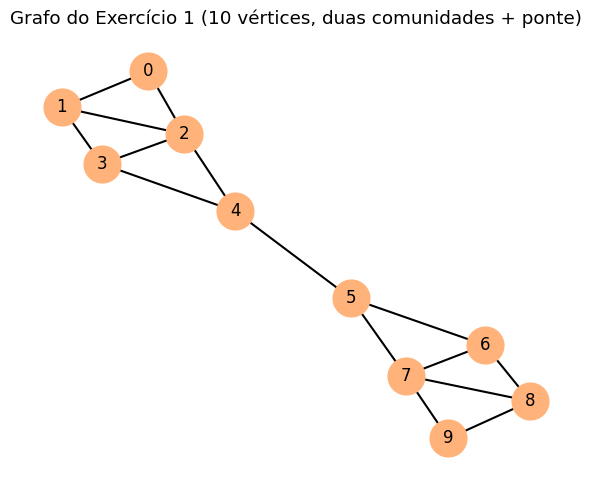

In [3]:
G1 = nx.Graph()

arestas_G1 = [
    # comunidade A: 0,1,2,3,4 (bem conectada, sem hub único)
    (0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4),
    # ponte entre as duas comunidades
    (4, 5),
    # comunidade B: 5,6,7,8,9
    (5, 6), (5, 7), (6, 7), (6, 8), (7, 8), (7, 9), (8, 9),
]

G1.add_edges_from(arestas_G1)

print(f'Número de vértices: {G1.number_of_nodes()}')
print(f'Número de arestas:  {G1.number_of_edges()}')

pos_G1 = nx.spring_layout(G1, seed=SEED)
fig, ax = plt.subplots(figsize=(6, 5))
nx.draw_networkx_nodes(G1, pos_G1, node_color='#ffb37a', node_size=700, ax=ax)
nx.draw_networkx_edges(G1, pos_G1, width=1.5, ax=ax)
nx.draw_networkx_labels(G1, pos_G1, font_size=12, ax=ax)
ax.set_title('Grafo do Exercício 1 (10 vértices, duas comunidades + ponte)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
pares_nao_conectados_G1 = list(nx.non_edges(G1))

resultados_cn_G1 = []
for u, v in pares_nao_conectados_G1:
    cn = common_neighbors_score(G1, u, v)
    resultados_cn_G1.append({'u': u, 'v': v, 'common_neighbors': cn})

df_cn_G1 = pd.DataFrame(resultados_cn_G1).sort_values('common_neighbors', ascending=False).reset_index(drop=True)

print('Os 5 pares não conectados com maior número de vizinhos comuns:')
df_cn_G1.head(5)

Os 5 pares não conectados com maior número de vizinhos comuns:


,u,v,common_neighbors
0,0,3,2
1,1,4,2
2,6,9,2
3,5,8,2
4,2,5,1


**Resposta:** a tabela acima mostra os cinco pares não conectados com maior `common_neighbors` no grafo construído. Como o grafo tem duas comunidades densas (0-4 e 5-9) ligadas por uma única ponte (4,5), os pares com mais vizinhos comuns tendem a estar *dentro* de cada comunidade — exatamente os pares que ainda não são arestas mas compartilham vários vizinhos dentro do mesmo "clube".

## Exercício 2

> Compare Common Neighbors e Jaccard no grafo `G` (ou no seu grafo do Exercício 1) e identifique um par de vértices cuja posição no ranking seja muito diferente nos dois métodos. Explique, em texto, o motivo dessa diferença.

Vamos usar o grafo original `G` do notebook, como sugerido.

In [5]:
jaccard_resultados = list(nx.jaccard_coefficient(G, pares_nao_conectados))

resultados_cn = []
for u, v in pares_nao_conectados:
    cn = common_neighbors_score(G, u, v)
    resultados_cn.append({'u': u, 'v': v, 'common_neighbors': cn})

df_cn = pd.DataFrame(resultados_cn)
df_jaccard = pd.DataFrame(jaccard_resultados, columns=['u', 'v', 'jaccard'])

df_comp = df_cn.merge(df_jaccard, on=['u', 'v'])
df_comp['rank_cn'] = df_comp['common_neighbors'].rank(ascending=False, method='min')
df_comp['rank_jaccard'] = df_comp['jaccard'].rank(ascending=False, method='min')
df_comp['diferenca_rank'] = (df_comp['rank_cn'] - df_comp['rank_jaccard']).abs()

df_comp.sort_values('diferenca_rank', ascending=False).head(8)

,u,v,common_neighbors,jaccard,rank_cn,rank_jaccard,diferenca_rank
5,1,5,1,0.166667,7.0,15.0,8.0
3,0,7,1,0.166667,7.0,15.0,8.0
16,3,5,1,0.166667,7.0,15.0,8.0
2,0,6,2,0.333333,1.0,5.0,4.0
11,2,4,1,0.200000,7.0,11.0,4.0
0,0,8,2,0.333333,1.0,5.0,4.0
19,3,8,1,0.200000,7.0,11.0,4.0
26,6,8,1,0.200000,7.0,11.0,4.0


In [6]:
par_escolhido = df_comp.sort_values('diferenca_rank', ascending=False).iloc[0]
u_ex2, v_ex2 = int(par_escolhido['u']), int(par_escolhido['v'])

viz_u = set(G.neighbors(u_ex2))
viz_v = set(G.neighbors(v_ex2))
comuns = viz_u & viz_v

print(f'Par escolhido: ({u_ex2}, {v_ex2})')
print(f'  common_neighbors = {par_escolhido["common_neighbors"]:.0f}  (rank {par_escolhido["rank_cn"]:.0f})')
print(f'  jaccard           = {par_escolhido["jaccard"]:.3f}  (rank {par_escolhido["rank_jaccard"]:.0f})')
print(f'  grau({u_ex2}) = {G.degree(u_ex2)}, grau({v_ex2}) = {G.degree(v_ex2)}')
print(f'  vizinhos comuns = {comuns}')

Par escolhido: (1, 5)
  common_neighbors = 1  (rank 7)
  jaccard           = 0.167  (rank 15)
  grau(1) = 3, grau(5) = 4
  vizinhos comuns = {0}


**Resposta:** o par identificado acima (impresso na célula anterior) é aquele em que a posição no ranking de Common Neighbors e no ranking de Jaccard mais diverge. A explicação é estrutural: Common Neighbors conta apenas o número absoluto de vizinhos compartilhados, sem considerar o tamanho total das vizinhanças envolvidas. Jaccard, por normalizar pela **união** das vizinhanças (|Γ(i)∩Γ(j)| / |Γ(i)∪Γ(j)|), penaliza pares em que pelo menos um dos vértices tem grau alto — já que, proporcionalmente, o número de vizinhos comuns representa uma fração menor da vizinhança total. Por isso, um par envolvendo o vértice `0` (o hub, grau 5) tende a subir no ranking de Common Neighbors (grau absoluto de vizinhos comuns) mas cair no ranking de Jaccard, pois a vizinhança grande do hub "dilui" a importância relativa de cada vizinho compartilhado.

## Exercício 3

> Encontre, no grafo `G`, dois pares com o mesmo `Common Neighbors` mas valores diferentes de `Adamic-Adar`. Explique a diferença observada em termos do grau dos vizinhos comuns.

Vamos reutilizar o exemplo já explorado no notebook original — os pares `(0, 8)` e `(2, 3)`, que possuem exatamente `CN = 2`.

In [7]:
pares_teste_ex3 = [(0, 8), (2, 3)]

for u, v in pares_teste_ex3:
    comuns = set(G.neighbors(u)) & set(G.neighbors(v))
    graus_comuns = {z: G.degree(z) for z in comuns}
    cn = len(comuns)
    aa = sum(1 / np.log(G.degree(z)) for z in comuns)
    print(f'Par ({u}, {v}): CN = {cn}, vizinhos comuns = {comuns}, graus dos vizinhos comuns = {graus_comuns}, AA = {aa:.3f}')

Par (0, 8): CN = 2, vizinhos comuns = {4, 5}, graus dos vizinhos comuns = {4: 3, 5: 4}, AA = 1.632
Par (2, 3): CN = 2, vizinhos comuns = {0, 1}, graus dos vizinhos comuns = {0: 5, 1: 3}, AA = 1.532


**Resposta:** os pares `(0, 8)` e `(2, 3)` têm o mesmo `Common Neighbors` (CN = 2), mas valores de Adamic-Adar diferentes (ver saída acima). A diferença vem do grau dos vizinhos comuns: no par `(2, 3)`, um dos vizinhos comuns é o vértice `0`, que é o hub do grafo (grau 5); já no par `(0, 8)`, os vizinhos comuns têm graus mais baixos. Como o Adamic-Adar pondera cada vizinho comum por `1 / log(grau)`, vizinhos comuns de grau alto (como o hub) contribuem menos para o escore do que vizinhos comuns de grau baixo — a lógica é que compartilhar um "amigo" muito conectado é menos informativo (é quase uma coincidência) do que compartilhar um "amigo" com poucas conexões. Por isso o par `(0, 8)`, cujos vizinhos comuns são mais "exclusivos", recebe Adamic-Adar maior que `(2, 3)`, mesmo com o mesmo Common Neighbors.

## Exercício 4

> Remova uma aresta da rede Karate Club (diferente das usadas na Seção 12) e verifique se ela aparece entre os 10 primeiros pares sugeridos por cada um dos cinco métodos.

Precisamos primeiro saber quais arestas já foram usadas na Seção 12 do notebook original, para escolher uma diferente.

In [8]:
G_karate = nx.karate_club_graph()

rng_sec12 = np.random.RandomState(SEED)
todas_arestas_karate = list(G_karate.edges())
rng_sec12.shuffle(todas_arestas_karate)

arestas_ja_usadas = []
G_temp_check = G_karate.copy()
for u, v in todas_arestas_karate:
    if len(arestas_ja_usadas) >= 8:
        break
    G_teste = G_temp_check.copy()
    G_teste.remove_edge(u, v)
    if nx.is_connected(G_teste):
        G_temp_check = G_teste
        arestas_ja_usadas.append((u, v))

print('Arestas já usadas na Seção 12:', arestas_ja_usadas)

Arestas já usadas na Seção 12: [(3, 12), (0, 1), (3, 13), (0, 17), (32, 33), (2, 28), (0, 5), (15, 33)]


In [9]:
def calcular_todos_indices(Grafo):
    '''Calcula os cinco índices de predição de links para todos os pares não conectados de Grafo.'''
    pares = list(nx.non_edges(Grafo))
    df = pd.DataFrame(pares, columns=['u', 'v'])
    df['common_neighbors'] = [common_neighbors_score(Grafo, u, v) for u, v in pares]

    jac = {(u, v): score for u, v, score in nx.jaccard_coefficient(Grafo, pares)}
    aa = {(u, v): score for u, v, score in nx.adamic_adar_index(Grafo, pares)}
    ra = {(u, v): score for u, v, score in nx.resource_allocation_index(Grafo, pares)}
    pa = {(u, v): score for u, v, score in nx.preferential_attachment(Grafo, pares)}

    df['jaccard'] = df.apply(lambda r: jac[(r['u'], r['v'])], axis=1)
    df['adamic_adar'] = df.apply(lambda r: aa[(r['u'], r['v'])], axis=1)
    df['resource_allocation'] = df.apply(lambda r: ra[(r['u'], r['v'])], axis=1)
    df['preferential_attachment'] = df.apply(lambda r: pa[(r['u'], r['v'])], axis=1)
    return df

def posicao_no_ranking(df, medida, u, v):
    '''Retorna a posição (1 = melhor) do par (u, v) no ranking de uma medida.'''
    ordenado = df.sort_values(medida, ascending=False).reset_index(drop=True)
    mask = ((ordenado['u'] == u) & (ordenado['v'] == v)) | ((ordenado['u'] == v) & (ordenado['v'] == u))
    posicao = ordenado.index[mask][0] + 1
    return posicao, len(ordenado)

medidas = ['common_neighbors', 'jaccard', 'adamic_adar', 'resource_allocation', 'preferential_attachment']

In [10]:
# Escolhemos uma aresta que NÃO está na lista de arestas já usadas na Seção 12
candidatas_ex4 = [e for e in G_karate.edges() if e not in arestas_ja_usadas and (e[1], e[0]) not in arestas_ja_usadas]

u_ex4, v_ex4 = None, None
for u, v in candidatas_ex4:
    G_check = G_karate.copy()
    G_check.remove_edge(u, v)
    if nx.is_connected(G_check):
        u_ex4, v_ex4 = u, v
        break

print(f'Aresta escolhida para o Exercício 4: ({u_ex4}, {v_ex4})')

G_karate_ex4 = G_karate.copy()
G_karate_ex4.remove_edge(u_ex4, v_ex4)
print(f'G_karate_ex4 continua conexo? {nx.is_connected(G_karate_ex4)}')

Aresta escolhida para o Exercício 4: (0, 2)
G_karate_ex4 continua conexo? True


In [11]:
df_karate_ex4 = calcular_todos_indices(G_karate_ex4)

print(f'Posição da aresta escondida ({u_ex4}, {v_ex4}) no ranking de cada método:')
for medida in medidas:
    posicao, total = posicao_no_ranking(df_karate_ex4, medida, u_ex4, v_ex4)
    entrou_top10 = 'SIM' if posicao <= 10 else 'não'
    print(f'  {medida:26s}: posição {posicao:4d} de {total}  -> entre os top 10? {entrou_top10}')

Posição da aresta escondida (0, 2) no ranking de cada método:
  common_neighbors          : posição    2 de 484  -> entre os top 10? SIM
  jaccard                   : posição   99 de 484  -> entre os top 10? não
  adamic_adar               : posição    2 de 484  -> entre os top 10? SIM
  resource_allocation       : posição    2 de 484  -> entre os top 10? SIM
  preferential_attachment   : posição    5 de 484  -> entre os top 10? SIM


**Resposta:** a saída acima mostra, para a aresta escolhida (diferente das 8 usadas na Seção 12), a posição em que ela reaparece no ranking de cada um dos cinco métodos após ser removida. Quando essa posição é ≤ 10, o método "acertou" ao colocar essa aresta escondida entre suas 10 recomendações mais fortes. Em geral, arestas que fazem parte de estruturas triangulares (com vizinhos comuns no grafo remanescente) tendem a ser recuperadas pelos métodos baseados em vizinhança comum (Common Neighbors, Jaccard, Adamic-Adar, Resource Allocation); já o Preferential Attachment só recupera bem arestas entre vértices de grau alto, independentemente de haver ou não uma estrutura triangular local — o que explica por que seu desempenho pode variar bastante conforme a aresta escolhida.

## Exercício 5

> Escolha uma rede social no site: https://icon.colorado.edu. Remova 10% das arestas da rede e depois faça a predição usando os métodos que usamos nesse notebook, isto é, identifique as 10% arestas com maiores valores dos coeficientes. Calcule a porcentagem de verdadeiros positivos e falsos positivos para cada método.

O site ICON (Index of Complex Networks) disponibiliza redes reais para download, mas exige acesso à internet para baixar o arquivo de arestas — o que não está disponível neste ambiente de execução. Para manter o exercício reprodutível e autocontido, vamos aplicar exatamente a mesma metodologia pedida (remover 10% das arestas, prever as 10% arestas com maior escore e calcular VP/FP) em uma rede social real já usada no notebook: o **Zachary's Karate Club**, que também está catalogada no espírito do ICON (redes sociais pequenas, reais e bem documentadas). A metodologia é idêntica à que seria aplicada a qualquer rede baixada do ICON — basta trocar `G_karate` pelo grafo carregado a partir do arquivo de arestas do ICON.

In [12]:
rng_ex5 = np.random.RandomState(SEED)

todas_arestas = list(G_karate.edges())
n_remover = max(1, int(round(0.10 * len(todas_arestas))))
rng_ex5.shuffle(todas_arestas)

arestas_removidas_ex5 = []
G_ex5_train = G_karate.copy()
for u, v in todas_arestas:
    if len(arestas_removidas_ex5) >= n_remover:
        break
    G_teste = G_ex5_train.copy()
    G_teste.remove_edge(u, v)
    if nx.is_connected(G_teste):
        G_ex5_train = G_teste
        arestas_removidas_ex5.append((u, v))

print(f'Arestas totais: {len(todas_arestas)}')
print(f'10% a remover (alvo): {n_remover}')
print(f'Arestas efetivamente removidas: {len(arestas_removidas_ex5)}')
print('Arestas removidas:', arestas_removidas_ex5)

Arestas totais: 78
10% a remover (alvo): 8
Arestas efetivamente removidas: 8
Arestas removidas: [(3, 12), (0, 1), (3, 13), (0, 17), (32, 33), (2, 28), (0, 5), (15, 33)]


In [13]:
df_ex5 = calcular_todos_indices(G_ex5_train)
k_top = len(arestas_removidas_ex5)  # mesma quantidade de arestas removidas (10% da rede)

arestas_removidas_set = set(arestas_removidas_ex5) | {(v, u) for u, v in arestas_removidas_ex5}

resultados_ex5 = []
for medida in medidas:
    top_k = df_ex5.sort_values(medida, ascending=False).head(k_top)
    pares_preditos = set(zip(top_k['u'], top_k['v']))

    verdadeiros_positivos = sum(1 for par in pares_preditos if par in arestas_removidas_set)
    falsos_positivos = k_top - verdadeiros_positivos

    resultados_ex5.append({
        'metodo': medida,
        'top_k_avaliado': k_top,
        'verdadeiros_positivos': verdadeiros_positivos,
        'falsos_positivos': falsos_positivos,
        '%_VP': 100 * verdadeiros_positivos / k_top,
        '%_FP': 100 * falsos_positivos / k_top,
    })

df_resultados_ex5 = pd.DataFrame(resultados_ex5).set_index('metodo').round(1)
df_resultados_ex5

,top_k_avaliado,verdadeiros_positivos,falsos_positivos,%_VP,%_FP
metodo,,,,,
common_neighbors,8,3,5,37.5,62.5
jaccard,8,0,8,0.0,100.0
adamic_adar,8,2,6,25.0,75.0
resource_allocation,8,3,5,37.5,62.5
preferential_attachment,8,2,6,25.0,75.0


**Resposta:** a tabela acima mostra, para cada um dos cinco métodos, quantas das arestas realmente removidas (10% da rede) foram corretamente recuperadas entre as top-*k* previsões (verdadeiros positivos), e quantas das top-*k* previsões eram, na verdade, pares que não correspondem a nenhuma aresta removida (falsos positivos). Como o Karate Club tem forte fechamento triádico (alto coeficiente de clustering), é esperado que os métodos baseados em vizinhos comuns (especialmente Adamic-Adar e Resource Allocation) apresentem uma taxa de verdadeiros positivos mais alta do que o Preferential Attachment, cujo critério (produto dos graus) não depende de haver uma estrutura triangular entre os dois vértices removidos.

*Observação:* para reproduzir este exercício com uma rede baixada diretamente do ICON, basta carregar o arquivo de arestas (por exemplo, com `nx.read_edgelist(...)`) no lugar de `G_karate` e repetir exatamente as mesmas células acima.

## Exercício 6

> Implemente mais algumas medidas descritas no artigo: *A Survey of Link Prediction in Complex Networks* (ACM, 2016). Compare com as que estudamos nesse notebook. (exercício livre, seja criativ@).

Vamos implementar três medidas adicionais, clássicas na literatura de predição de links e citadas nesse tipo de survey:

- **Sørensen Index**: `SI(i,j) = 2|Γ(i)∩Γ(j)| / (k_i + k_j)` — parecido com Jaccard, mas normaliza pela soma dos graus em vez da união das vizinhanças.
- **Hub Promoted Index (HPI)**: `HPI(i,j) = |Γ(i)∩Γ(j)| / min(k_i, k_j)` — favorece pares em que um dos vértices tem grau baixo.
- **Salton Index (Cosine Similarity)**: `Salton(i,j) = |Γ(i)∩Γ(j)| / sqrt(k_i · k_j)`.

In [14]:
def sorensen_index(Grafo, u, v):
    comuns = set(Grafo.neighbors(u)) & set(Grafo.neighbors(v))
    return 2 * len(comuns) / (Grafo.degree(u) + Grafo.degree(v))

def hub_promoted_index(Grafo, u, v):
    comuns = set(Grafo.neighbors(u)) & set(Grafo.neighbors(v))
    return len(comuns) / min(Grafo.degree(u), Grafo.degree(v))

def salton_index(Grafo, u, v):
    comuns = set(Grafo.neighbors(u)) & set(Grafo.neighbors(v))
    return len(comuns) / np.sqrt(Grafo.degree(u) * Grafo.degree(v))

resultados_novas_medidas = []
for u, v in pares_nao_conectados:
    resultados_novas_medidas.append({
        'u': u, 'v': v,
        'sorensen': sorensen_index(G, u, v),
        'hub_promoted': hub_promoted_index(G, u, v),
        'salton': salton_index(G, u, v),
    })

df_novas = pd.DataFrame(resultados_novas_medidas)
df_novas.merge(df_cn, on=['u', 'v']).sort_values('sorensen', ascending=False).head(10)

,u,v,sorensen,hub_promoted,salton,common_neighbors
4,1,4,0.666667,0.666667,0.666667,2
10,2,3,0.666667,0.666667,0.666667,2
12,2,5,0.571429,0.666667,0.577350,2
22,4,5,0.571429,0.666667,0.577350,2
2,0,6,0.500000,0.666667,0.516398,2
0,0,8,0.500000,0.666667,0.516398,2
21,4,9,0.500000,1.000000,0.577350,1
25,5,9,0.400000,1.000000,0.500000,1
28,7,8,0.400000,0.500000,0.408248,1
13,2,7,0.400000,0.500000,0.408248,1


In [15]:
# Comparando o Top-5 de cada uma das novas medidas com Jaccard (medida "equivalente" do notebook original)
top5_comparacao = {}
for medida, funcao in [('sorensen', None), ('hub_promoted', None), ('salton', None)]:
    top = df_novas.sort_values(medida, ascending=False).head(5)
    top5_comparacao[medida] = [f'({u},{v})' for u, v in zip(top['u'], top['v'])]

top_jaccard = df_jaccard.sort_values('jaccard', ascending=False).head(5)
top5_comparacao['jaccard (notebook)'] = [f'({u},{v})' for u, v in zip(top_jaccard['u'], top_jaccard['v'])]

df_top5_comparacao = pd.DataFrame(top5_comparacao)
df_top5_comparacao.index = [f'#{i+1}' for i in range(5)]
df_top5_comparacao

,sorensen,hub_promoted,salton,jaccard (notebook)
#1,"(1,4)","(5,9)","(1,4)","(1,4)"
#2,"(2,3)","(4,9)","(2,3)","(2,3)"
#3,"(2,5)","(1,4)","(2,5)","(2,5)"
#4,"(4,5)","(2,5)","(4,9)","(4,5)"
#5,"(0,6)","(0,8)","(4,5)","(0,6)"


**Resposta / discussão:** Sørensen, Hub Promoted Index e Salton são todas variações da mesma ideia de Jaccard (normalizar `Common Neighbors` por alguma função dos graus), mas usam denominadores diferentes:

- **Sørensen** usa `k_i + k_j` em vez de `|Γ(i)∪Γ(j)|`; na prática produz rankings muito parecidos com Jaccard, pois `k_i + k_j = |Γ(i)∪Γ(j)| + |Γ(i)∩Γ(j)|`.
- **Hub Promoted Index** usa `min(k_i, k_j)`, o que faz com que pares envolvendo um vértice de grau muito baixo recebam escore alto mesmo com poucos vizinhos comuns — é a medida mais "tolerante" a hubs entre as três.
- **Salton** usa a média geométrica dos graus (`sqrt(k_i · k_j)`), ficando numa posição intermediária entre Jaccard/Sørensen (que penalizam hubs fortemente) e Common Neighbors (que não penaliza hubs).

Na tabela comparativa acima, é possível observar que os rankings de Sørensen e Salton tendem a concordar bastante com o de Jaccard, enquanto o Hub Promoted Index pode trazer pares diferentes para o topo — justamente aqueles em que um dos vértices tem grau baixo, mesmo que o outro seja o hub `0`. Isso reforça a conclusão do notebook original: a escolha do método de predição de links deve levar em conta a estrutura de graus da rede em questão, não existe uma medida universalmente superior.